<a href="https://colab.research.google.com/github/Ab11d/UsedCarPricePrediction/blob/main/UsedCarPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("car_prices.csv")
df.head()
df.head()

,car_id,brand,model,year,km_driven,fuel,transmission,owner,engine_cc,seats,city,color,insurance,price_inr
0,C0001,Maruti,Wagon R,2021,59508.0,Diesel,Manual,4,1498.0,5,Kolkata,Red,Comprehensive,785877
1,C0002,Mahindra,Scorpio,2016,104688.0,Diesel,Manual,1,2993.0,5,Ahmedabad,White,Third Party,1305523
2,C0003,Hyundai,Grand i10,2021,68005.0,CNG,Automatic,1,1497.0,5,Mumbai,White,Comprehensive,1164437
3,C0004,Renault,Triber,2018,71279.0,Petrol,Manual,1,2993.0,5,Delhi,Silver,Comprehensive,1079477
4,C0005,Renault,Duster,2015,93918.0,Petrol,Automatic,2,2755.0,5,Ahmedabad,Black,Third Party,897128


In [ ]:
# Number of rows and columns
print("Shape:", df.shape)

# Information about columns and data types
df.info()

# Basic statistics
df.describe()

# Check for missing values
print(df.isnull().sum())

Shape: (500, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car_id        500 non-null    object 
 1   brand         500 non-null    object 
 2   model         500 non-null    object 
 3   year          500 non-null    int64  
 4   km_driven     500 non-null    float64
 5   fuel          500 non-null    object 
 6   transmission  500 non-null    object 
 7   owner         500 non-null    int64  
 8   engine_cc     500 non-null    float64
 9   seats         500 non-null    int64  
 10  city          500 non-null    object 
 11  color         500 non-null    object 
 12  insurance     500 non-null    object 
 13  price_inr     500 non-null    int64  
dtypes: float64(2), int64(4), object(8)
memory usage: 54.8+ KB
car_id          0
brand           0
model           0
year            0
km_driven       0
fuel            0
transmission    0
o

In [ ]:
# y = the value we want the model to predict
y = df["price_inr"]

# X = information that the model will use to make the prediction
# We remove price_inr because that is what we're trying to predict.
# We also remove car_id because it is only an identifier.
X = df.drop(["price_inr", "car_id"], axis=1)

In [ ]:
# Separating the categories of features in preparation for the ml
# model's training.
numerical_features = [
"year",
"km_driven",
"owner",
"engine_cc",
"seats"]

categorical_features = [
"brand",
"model",
"fuel",
"transmission",
"city",
"color",
"insurance"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, # Input features
y, # Target
test_size=0.2, # 20% will be used for testing
random_state=42 # Makes the split reproducible
)

print("Training data:", X.shape)
print("Testing data:", X.shape)

Training data: (500, 12)
Testing data: (500, 12)


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# Create an encoder

encoder = OneHotEncoder(
  handle_unknown="ignore")

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
# Define how each type of column should be processed
preprocessor = ColumnTransformer(
  transformers=[
# Numerical columns:
# "passthrough" means leave them unchanged
("num",
"passthrough",
numerical_features),
# Categorical columns:
# Convert them into numerical values
("cat", OneHotEncoder(handle_unknown="ignore"),
categorical_features)
])

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
regressor = LinearRegression()

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
# Create a pipeline
# First: preprocess the data
# Second: train Linear Regression
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [ ]:
# Train the model using our training data
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['year', 'km_driven', 'owner',
                                                   'engine_cc', 'seats']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'model', 'fuel',
                                                   'transmission', 'city',
                                                   'color', 'insurance'])])),
                ('regressor', LinearRegression())])

In [ ]:
# Ask the trained model to predict prices
predictions = model.predict(X_test)

In [ ]:
# Show the first 10 actual prices
print("Actual prices:")
print(y_test.iloc[:10].values)

# Show the first 10 predicted prices
print("\nPredicted prices:")
print(predictions[:10])

Actual prices:
[1572868 1086049 1354226  923936 1299851  731310 1078687 2436311 1213543
 1173446]

Predicted prices:
[1292714.48100021 1094341.32342599 1165411.32399285 1009575.43961157
 1240157.64333341  867093.90695998  983477.56102097 2386069.50828262
 1192092.84469464 1090338.57565145]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

print("MODEL PERFORMANCE")
print("-------------------------")
print(f"MAE: ₹{mae:,.0f}")
print(f"RMSE: ₹{rmse:,.0f}")
print(f"R²: {r2:.3f}")

MODEL PERFORMANCE
-------------------------
MAE: ₹71,777
RMSE: ₹91,267
R²: 0.941


In [ ]:
import matplotlib.pyplot as plt

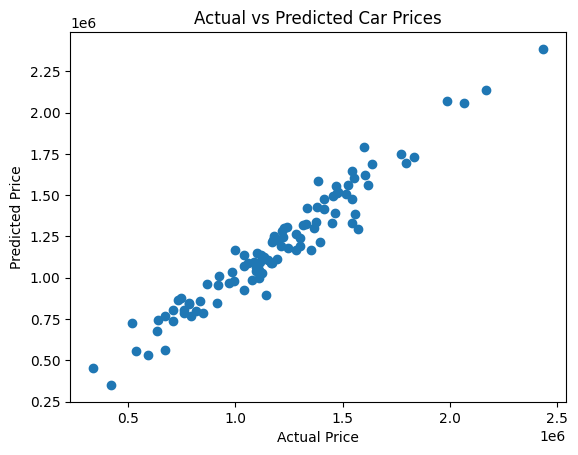

In [ ]:
# Create a scatter plot
plt.scatter(y_test, predictions)
# X-axis = actual prices
plt.xlabel("Actual Price")
# Y-axis = predicted prices
plt.ylabel("Predicted Price")
# Title
plt.title("Actual vs Predicted Car Prices")
# Show the graph
plt.show()

In [ ]:
# Create information about a new car
new_car = pd.DataFrame({
"brand": ["Maruti"],
"model": ["Wagon R"],
"year": [2020],
"km_driven": [45000],
"fuel": ["Petrol"],
"transmission": ["Manual"],
"owner": [1],
"engine_cc": [1197],
"seats": [5],
"city": ["Mumbai"],
"color": ["White"],
"insurance": ["Comprehensive"]
})

In [ ]:
# Predict the price of our new car
predicted_price = model.predict(new_car)
# Display the prediction
print(f"Estimated Car Price: ₹{predicted_price[0]:,.0f}")

Estimated Car Price: ₹871,816


In [ ]:
import joblib

# Save the entire pipeline (preprocessor + model) as one file
joblib.dump(model, "car_price_model.joblib")

['car_price_model.joblib']

In [ ]:
from google.colab import files
files.download("car_price_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>